In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [3]:
import pandas as pd
import os

# Point this to your data directory
DATA_DIR = "../data"  # adjust if needed

files = sorted([f for f in os.listdir(DATA_DIR) if f.endswith(".csv")])
print(f"Found {len(files)} files\n")

col_report = {}
shape_report = {}
dtype_report = {}

for f in files:
    path = os.path.join(DATA_DIR, f)
    df = pd.read_csv(path, nrows=5)
    col_report[f] = list(df.columns)
    dtype_report[f] = dict(df.dtypes.astype(str))

# Full read for shape
for f in files:
    path = os.path.join(DATA_DIR, f)
    df = pd.read_csv(path)
    shape_report[f] = df.shape

# ── Column consistency check ──────────────────────────────
reference_file = files[0]
reference_cols = col_report[reference_file]
print(f"Reference columns ({reference_file}):")
print(reference_cols, "\n")

all_match = True
for f, cols in col_report.items():
    if cols != reference_cols:
        all_match = False
        missing = set(reference_cols) - set(cols)
        extra   = set(cols) - set(reference_cols)
        print(f"  {f}")
        if missing: print(f"    Missing: {missing}")
        if extra:   print(f"    Extra:   {extra}")

if all_match:
    print(" All files have identical columns")

# ── Shape report ──────────────────────────────────────────
print("\n── Row counts ──")
for f, (rows, cols) in shape_report.items():
    print(f"  {f:<40} {rows:>6} rows  {cols} cols")

print("\n── Dtype mismatches vs reference ──")
ref_dtypes = dtype_report[reference_file]
any_dtype_mismatch = False
for f, dtypes in dtype_report.items():
    diff = {col: (ref_dtypes.get(col), dtypes.get(col)) 
            for col in set(ref_dtypes) | set(dtypes)
            if ref_dtypes.get(col) != dtypes.get(col)}
    if diff:
        any_dtype_mismatch = True
        print(f" {f}: {diff}")

if not any_dtype_mismatch:
    print("All dtypes consistent")

Found 18 files

Reference columns (A.Zhandong Road1.csv):
['frame_num', 'id', 'name', 'xmin', 'ymin', 'xmax', 'ymax', 'speed', 'turn', 'acceleration', 'UP', 'RIGHT', 'DOWN', 'LEFT'] 

 All files have identical columns

── Row counts ──
  A.Zhandong Road1.csv                     2362666 rows  14 cols
  A.Zhandong Road2.csv                     1092047 rows  14 cols
  B.Dongying Road1.csv                     2830210 rows  14 cols
  B.Dongying Road2.csv                     2098482 rows  14 cols
  C.Ulanqab East Street1.csv               772954 rows  14 cols
  C.Ulanqab East Street2.csv               556170 rows  14 cols
  C.Ulanqab East Street3.csv               566874 rows  14 cols
  C.Ulanqab East Street4.csv               1330283 rows  14 cols
  D.Xing'an South Road1.csv                721685 rows  14 cols
  D.Xing'an South Road2.csv                1138093 rows  14 cols
  E.People's Hall1.csv                     1238327 rows  14 cols
  E.People's Hall2.csv                     678728 row

In [4]:
import pandas as pd

path = "../data/H.Zhongshan  Road2.csv"
df = pd.read_csv(path)

print("turn column value counts (including NaN):")
print(df['turn'].value_counts(dropna=False).head(20))

print(f"\nNull count: {df['turn'].isna().sum()}")
print(f"Total rows: {len(df)}")
print(f"% null: {df['turn'].isna().sum()/len(df)*100:.2f}%")

turn column value counts (including NaN):
turn
NaN      1598743
RIGHT     416091
LEFT      320043
DOWN      124626
UP         93625
Name: count, dtype: int64

Null count: 1598743
Total rows: 2553128
% null: 62.62%


In [5]:
df = pd.read_csv("../data/A.Zhandong Road1.csv", nrows=100000)

# Check if UP/RIGHT/DOWN/LEFT are just one-hot of turn
print(df.groupby('turn')[['UP','RIGHT','DOWN','LEFT']].mean().round(2))

# Also check what % of rows have speed = 0
print(f"\nSpeed = 0: {(df['speed']==0).sum()/len(df)*100:.1f}%")
print(f"Speed > 0: {(df['speed']>0).sum()/len(df)*100:.1f}%")

# Frame range
print(f"\nFrame range: {df['frame_num'].min()} to {df['frame_num'].max()}")
print(f"Unique frames: {df['frame_num'].nunique()}")
print(f"Avg vehicles per frame: {len(df)/df['frame_num'].nunique():.1f}")

          UP  RIGHT   DOWN   LEFT
turn                             
DOWN    9.85  10.34  11.39   9.03
LEFT    9.51  10.75   9.90   9.76
RIGHT   9.61  12.54  10.06   9.28
UP     14.31  13.64  12.08  11.37

Speed = 0: 59.5%
Speed > 0: 35.0%

Frame range: 6 to 1070
Unique frames: 1065
Avg vehicles per frame: 93.9


In [6]:
df = pd.read_csv("../data/A.Zhandong Road1.csv", nrows=100000)

# Check UP/RIGHT/DOWN/LEFT value ranges
print("Value ranges:")
for col in ['UP','RIGHT','DOWN','LEFT']:
    print(f"  {col}: min={df[col].min()}, max={df[col].max()}, unique={df[col].nunique()}")

# Speed=0 but has turn direction?
speed_zero_with_turn = df[(df['speed']==0) & (df['turn'].notna())]
print(f"\nSpeed=0 but has turn: {len(speed_zero_with_turn)} rows")

# Negative speeds?
print(f"Negative speed rows: {(df['speed']<0).sum()}")
print(f"Speed describe:\n{df['speed'].describe()}")

# Are IDs consistent across frames (vehicle tracking)?
print(f"\nUnique vehicle IDs: {df['id'].nunique()}")
print(f"Max ID appearances: {df.groupby('id').size().max()}")
print(f"Avg ID appearances: {df.groupby('id').size().mean():.1f}")

Value ranges:
  UP: min=0, max=48, unique=49
  RIGHT: min=0, max=41, unique=42
  DOWN: min=0, max=47, unique=48
  LEFT: min=0, max=29, unique=30

Speed=0 but has turn: 31 rows
Negative speed rows: 5446
Speed describe:
count    100000.000000
mean          5.327071
std           9.900491
min          -5.400000
25%           0.000000
50%           0.000000
75%           5.486000
max          66.029000
Name: speed, dtype: float64

Unique vehicle IDs: 193
Max ID appearances: 1065
Avg ID appearances: 518.1


In [7]:
df = pd.read_csv("../data/A.Zhandong Road1.csv")

# Are UP/RIGHT/DOWN/LEFT monotonically increasing per frame?
frame_agg = df.groupby('frame_num')[['UP','RIGHT','DOWN','LEFT']].max()
print("Are lane counts always increasing across frames?")
print((frame_agg.diff().dropna() >= 0).all())

# Per-frame aggregation — what your clustering features should look like
frame_features = df.groupby('frame_num').agg(
    vehicle_count   = ('id', 'nunique'),
    avg_speed       = ('speed', 'mean'),
    std_speed       = ('speed', 'std'),
    pct_stopped     = ('speed', lambda x: (x == 0).mean()),
    max_speed       = ('speed', 'max'),
    turning_vehicles= ('turn', lambda x: x.notna().sum()),
    up_flow         = ('UP', 'max'),
    right_flow      = ('RIGHT', 'max'),
    down_flow       = ('DOWN', 'max'),
    left_flow       = ('LEFT', 'max'),
).reset_index()

print("\nPer-frame features shape:", frame_features.shape)
print(frame_features.describe().round(2))

Are lane counts always increasing across frames?
UP       False
RIGHT    False
DOWN     False
LEFT     False
dtype: bool

Per-frame features shape: (24903, 11)
       frame_num  vehicle_count  avg_speed  std_speed  pct_stopped  max_speed  \
count   24903.00       24903.00   24903.00   24903.00     24903.00   24903.00   
mean    12457.00          94.87       9.90      11.09         0.44      40.45   
std      7189.02           9.34       5.18       1.72         0.17       7.49   
min         6.00          69.00       2.65       6.41         0.00      20.91   
25%      6231.50          88.00       5.64       9.82         0.26      35.66   
50%     12457.00          94.00       7.17      10.96         0.49      39.94   
75%     18682.50         101.00      15.76      12.61         0.59      44.23   
max     24908.00         123.00      44.28      20.83         0.81      83.00   

       turning_vehicles   up_flow  right_flow  down_flow  left_flow  
count          24903.00  24903.00    249

In [8]:
df = pd.read_csv("../data/A.Zhandong Road1.csv")

# How are frame_nums distributed?
print("Total rows:", len(df))
print("Unique frames:", df['frame_num'].nunique())
print("Frame num sample:", sorted(df['frame_num'].unique())[:20])
print("Are frame_nums contiguous?", 
      df['frame_num'].nunique() == df['frame_num'].max() - df['frame_num'].min() + 1)

# Look at UP for a single vehicle across frames — is it their personal counter?
sample_id = df['id'].value_counts().index[0]  # most frequent vehicle
vehicle_track = df[df['id']==sample_id][['frame_num','speed','UP','RIGHT','DOWN','LEFT']].head(20)
print(f"\nVehicle {sample_id} across frames:")
print(vehicle_track.to_string())

Total rows: 2362666
Unique frames: 24903
Frame num sample: [np.int64(6), np.int64(7), np.int64(8), np.int64(9), np.int64(10), np.int64(11), np.int64(12), np.int64(13), np.int64(14), np.int64(15), np.int64(16), np.int64(17), np.int64(18), np.int64(19), np.int64(20), np.int64(21), np.int64(22), np.int64(23), np.int64(24), np.int64(25)]
Are frame_nums contiguous? True

Vehicle 92 across frames:
      frame_num  speed  UP  RIGHT  DOWN  LEFT
91            6  0.000  15     14    19    19
198           7  0.000  23     10    15    17
306           8 -0.514  19     18    21    17
415           9  1.286  17     16    23    20
524          10  5.486  18     17    18    14
632          11  8.486  13     15    24    22
742          12  5.486  24     17    17    17
851          13  1.286  19     10    17    18
962          14 -0.514  20     14    23    17
1072         15  0.000  17     15    26    20
1182         16  0.000  27     14    14    19
1293         17  0.000  16     13    13    20
1403   

In [9]:
import pandas as pd
import os

DATA_DIR = "../data"
files = sorted([f for f in os.listdir(DATA_DIR) if f.endswith(".csv")])

all_features = []

for f in files:
    path = os.path.join(DATA_DIR, f)
    df = pd.read_csv(path)
    
    # Clip negative speeds — tracking artifact
    df['speed'] = df['speed'].clip(lower=0)
    
    # Per-frame aggregation
    frame_features = df.groupby('frame_num').agg(
        vehicle_count    = ('id', 'nunique'),
        avg_speed        = ('speed', 'mean'),
        std_speed        = ('speed', 'std'),
        pct_stopped      = ('speed', lambda x: (x == 0).mean()),
        median_speed     = ('speed', 'median'),
        turning_vehicles = ('turn', lambda x: x.notna().sum()),
        pct_turning      = ('turn', lambda x: x.notna().mean()),
        up_flow          = ('UP', 'max'),      # same value per frame, just recover it
        right_flow       = ('RIGHT', 'max'),
        down_flow        = ('DOWN', 'max'),
        left_flow        = ('LEFT', 'max'),
    ).reset_index()
    
    # Derived features
    frame_features['total_flow'] = (frame_features['up_flow'] + 
                                    frame_features['right_flow'] +
                                    frame_features['down_flow'] + 
                                    frame_features['left_flow'])
    frame_features['flow_imbalance'] = (frame_features[['up_flow','right_flow',
                                                          'down_flow','left_flow']]
                                        .std(axis=1))
    frame_features['source'] = f.replace('.csv', '')
    all_features.append(frame_features)

master = pd.concat(all_features, ignore_index=True)
print(f"Master shape: {master.shape}")
print(f"Sources: {master['source'].nunique()}")
print(master.describe().round(2))

Master shape: (271245, 15)
Sources: 18
       frame_num  vehicle_count  avg_speed  std_speed  pct_stopped  \
count  271245.00      271245.00  271245.00  271245.00    271245.00   
mean     8973.38          97.82       8.39      11.17         0.55   
std      6255.66          28.08       3.97       2.53         0.15   
min         6.00           2.00       0.00       0.00         0.00   
25%      3773.00          81.00       5.47       9.43         0.44   
50%      7920.00          93.00       7.34      11.18         0.56   
75%     13147.00         106.00      11.13      12.88         0.66   
max     24908.00         204.00      55.16      32.52         1.00   

       median_speed  turning_vehicles  pct_turning    up_flow  right_flow  \
count     271245.00         271245.00    271245.00  271245.00   271245.00   
mean           3.16             38.33         0.40      13.40       21.55   
std            5.78             16.23         0.15       7.63       10.75   
min            0.00   

Clustering input shape: (271245, 8)
k=2  inertia=1254902  silhouette=0.4143
k=3  inertia=949420  silhouette=0.3965
k=4  inertia=726435  silhouette=0.3362
k=5  inertia=641264  silhouette=0.2627
k=6  inertia=561911  silhouette=0.2711
k=7  inertia=508767  silhouette=0.2593
k=8  inertia=470914  silhouette=0.2476
k=9  inertia=440069  silhouette=0.2377


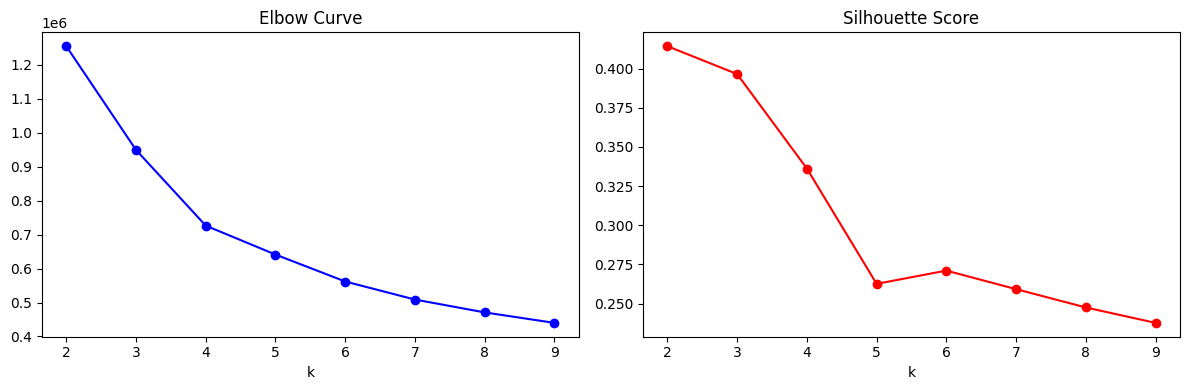

Saved elbow_silhouette.png


In [10]:
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np

# Features to cluster on — drop frame_num, source (non-numeric/identifier)
feature_cols = [
    'vehicle_count', 'avg_speed', 'std_speed', 'pct_stopped',
    'median_speed', 'pct_turning', 'total_flow', 'flow_imbalance'
]
# Note: dropping individual up/right/down/left flows — total_flow + imbalance captures them
# Note: dropping turning_vehicles (raw count) — pct_turning is scale-invariant

X = master[feature_cols].dropna()
print(f"Clustering input shape: {X.shape}")

# Scale
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# Elbow + Silhouette to find optimal k
inertias = []
silhouettes = []
K = range(2, 10)

for k in K:
    km = KMeans(n_clusters=k, random_state=42, n_init=10)
    labels = km.fit_predict(X_scaled)
    inertias.append(km.inertia_)
    silhouettes.append(silhouette_score(X_scaled, labels, sample_size=10000))
    print(f"k={k}  inertia={km.inertia_:.0f}  silhouette={silhouettes[-1]:.4f}")

# Plot
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))
ax1.plot(K, inertias, 'bo-')
ax1.set_xlabel('k'); ax1.set_title('Elbow Curve')
ax2.plot(K, silhouettes, 'ro-')
ax2.set_xlabel('k'); ax2.set_title('Silhouette Score')
plt.tight_layout()
plt.savefig('elbow_silhouette.png', dpi=150)
plt.show()
print("Saved elbow_silhouette.png")

In [11]:
# Step 1: Fit k=3 as pragmatic baseline
km3 = KMeans(n_clusters=3, random_state=42, n_init=10)
master['cluster_k3'] = km3.fit_predict(X_scaled)

# Interpret clusters by their feature means
cluster_profile = master.groupby('cluster_k3')[feature_cols].mean().round(2)
cluster_profile['frame_count'] = master.groupby('cluster_k3').size()
print(cluster_profile.sort_values('avg_speed'))

            vehicle_count  avg_speed  std_speed  pct_stopped  median_speed  \
cluster_k3                                                                   
0                  158.31       5.15       8.44         0.66          0.24   
2                   88.34       6.77      10.72         0.60          0.41   
1                   93.52      13.80      13.50         0.36         11.16   

            pct_turning  total_flow  flow_imbalance  frame_count  
cluster_k3                                                        
0                  0.30      103.52           10.78        31577  
2                  0.34       63.31            5.96       169818  
1                  0.60       80.62           14.60        69850  


In [13]:
# Step 2: HDBSCAN
import hdbscan

clusterer = hdbscan.HDBSCAN(
    min_cluster_size=500,    # minimum frames to form a cluster
    min_samples=50,
    metric='euclidean'
)
master['cluster_hdb'] = clusterer.fit_predict(X_scaled)

print("HDBSCAN cluster counts:")
print(master['cluster_hdb'].value_counts())
# -1 = noise points that didn't fit any cluster

HDBSCAN cluster counts:
cluster_hdb
-1    125060
 3    112920
 1     16292
 4     14442
 0      1417
 2      1114
Name: count, dtype: int64


In [14]:
# Check if cluster profiles differ by source
print(master.groupby('source')['avg_speed'].mean().sort_values())
print()
print(master.groupby('source')['pct_stopped'].mean().sort_values())

source
B.Dongying Road2           4.978955
B.Dongying Road1           5.438268
H.Zhongshan  Road1         7.251960
D.Xing'an South Road2      7.321986
H.Zhongshan  Road2         7.501182
C.Ulanqab East Street4     7.785955
F.South intersection2      8.287501
C.Ulanqab East Street1     8.425471
G.Xinhua Square2           8.470357
C.Ulanqab East Street3     8.626404
G.Xinhua Square1           8.759944
D.Xing'an South Road1      9.060790
F.South intersection1      9.357361
E.People's Hall1           9.713528
C.Ulanqab East Street2     9.872359
A.Zhandong Road1           9.922287
A.Zhandong Road2           9.960495
E.People's Hall2          12.048074
Name: avg_speed, dtype: float64

source
E.People's Hall2          0.456953
A.Zhandong Road2          0.459159
G.Xinhua Square2          0.470104
A.Zhandong Road1          0.482544
F.South intersection2     0.502100
D.Xing'an South Road1     0.525504
E.People's Hall1          0.534052
F.South intersection1     0.534770
D.Xing'an South Road2    

In [ ]:
import pandas as pd
import numpy as np
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
import warnings
warnings.filterwarnings('ignore')

feature_cols = [
    'vehicle_count', 'avg_speed', 'std_speed', 'pct_stopped',
    'median_speed', 'pct_turning', 'total_flow', 'flow_imbalance'
]

def label_cluster(row):
    """Convert numeric cluster to traffic state based on speed/stopping"""
    if row['avg_speed'] < 3 and row['pct_stopped'] > 0.7:
        return 'gridlock'
    elif row['avg_speed'] < 7 and row['pct_stopped'] > 0.5:
        return 'heavy_congestion'
    elif row['avg_speed'] < 15:
        return 'mild_congestion'
    else:
        return 'free_flow'

results = []
source_summaries = []

for source in sorted(master['source'].unique()):
    subset = master[master['source'] == source].copy()
    X = subset[feature_cols].dropna()
    
    if len(X) < 100:
        print(f" Skipping {source} — too few rows ({len(X)})")
        continue

    # Scale within this source only — removes cross-location baseline differences
    scaler = StandardScaler()
    X_scaled = scaler.fit_transform(X)

    # Find best k for this source (k=2 to 6)
    best_k, best_score = 2, -1
    for k in range(2, 7):
        km = KMeans(n_clusters=k, random_state=42, n_init=10)
        labels = km.fit_predict(X_scaled)
        score = silhouette_score(X_scaled, labels, sample_size=min(5000, len(X)))
        if score > best_score:
            best_score = score
            best_k = k

    # Fit final model with best k
    km_final = KMeans(n_clusters=best_k, random_state=42, n_init=10)
    subset = subset.loc[X.index].copy()
    subset['cluster'] = km_final.fit_predict(X_scaled)

    # Build cluster profiles for this source
    profile = subset.groupby('cluster')[feature_cols].mean()
    profile['frame_count'] = subset.groupby('cluster').size()
    profile['traffic_state'] = profile.apply(label_cluster, axis=1)
    profile['source'] = source
    profile['best_k'] = best_k
    profile['silhouette'] = round(best_score, 4)

    source_summaries.append(profile.reset_index())

    # Tag each frame with its traffic state
    cluster_to_state = profile['traffic_state'].to_dict()
    subset['traffic_state'] = subset['cluster'].map(cluster_to_state)
    results.append(subset)

    print(f" {source:<45} k={best_k}  silhouette={best_score:.4f}")
    print(profile[['avg_speed','pct_stopped','frame_count','traffic_state']].to_string())
    print()

# Combine everything
master_clustered = pd.concat(results, ignore_index=True)
summary_df = pd.concat(source_summaries, ignore_index=True)

print("=" * 60)
print("OVERALL TRAFFIC STATE DISTRIBUTION")
print(master_clustered['traffic_state'].value_counts())
print()
print("PER SOURCE BREAKDOWN")
print(master_clustered.groupby(['source','traffic_state']).size().unstack(fill_value=0))

✅ A.Zhandong Road1                              k=2  silhouette=0.6239
         avg_speed  pct_stopped  frame_count     traffic_state
cluster                                                       
0         6.157181     0.608820        15601  heavy_congestion
1        16.236996     0.270759         9302         free_flow

✅ A.Zhandong Road2                              k=2  silhouette=0.5580
         avg_speed  pct_stopped  frame_count    traffic_state
cluster                                                      
0        17.255199     0.263101         3224        free_flow
1         7.543669     0.524115         9731  mild_congestion

✅ B.Dongying Road1                              k=2  silhouette=0.5268
         avg_speed  pct_stopped  frame_count    traffic_state
cluster                                                      
0         2.974657     0.751752         9998         gridlock
1         9.227098     0.514777         6501  mild_congestion

✅ B.Dongying Road2                  

In [17]:
import pandas as pd
import numpy as np
import os

DATA_DIR = "../data"
files = sorted([f for f in os.listdir(DATA_DIR) if f.endswith(".csv")])

all_features = []

for f in files:
    path = os.path.join(DATA_DIR, f)
    df = pd.read_csv(path)
    df['speed'] = df['speed'].clip(lower=0)

    frame_features = df.groupby('frame_num').agg(
        vehicle_count    = ('id', 'nunique'),
        avg_speed        = ('speed', 'mean'),
        std_speed        = ('speed', 'std'),
        pct_stopped      = ('speed', lambda x: (x == 0).mean()),
        median_speed     = ('speed', 'median'),
        pct_turning      = ('turn', lambda x: x.notna().mean()),
        total_flow       = ('UP', 'max'),
        up_flow          = ('UP', 'max'),
        right_flow       = ('RIGHT', 'max'),
        down_flow        = ('DOWN', 'max'),
        left_flow        = ('LEFT', 'max'),
    ).reset_index()

    frame_features['total_flow'] = (frame_features['up_flow'] +
                                    frame_features['right_flow'] +
                                    frame_features['down_flow'] +
                                    frame_features['left_flow'])
    frame_features['flow_imbalance'] = frame_features[
        ['up_flow','right_flow','down_flow','left_flow']
    ].std(axis=1)
    frame_features['source'] = f.replace('.csv', '')
    all_features.append(frame_features)

master = pd.concat(all_features, ignore_index=True)

# ── Congestion score per location ─────────────────────────
def compute_congestion_score(group):
    # Speed component: normalize inverted speed (slow = high score)
    spd = group['avg_speed']
    spd_score = 1 - (spd - spd.min()) / (spd.max() - spd.min() + 1e-9)

    # Stopping component: normalize pct_stopped (more stopped = high score)
    stp = group['pct_stopped']
    stp_score = (stp - stp.min()) / (stp.max() - stp.min() + 1e-9)

    # Weighted combination — speed carries more signal
    group = group.copy()
    group['congestion_score'] = 0.6 * spd_score + 0.4 * stp_score
    return group

master = master.groupby('source', group_keys=False).apply(compute_congestion_score)

# ── Sanity check ──────────────────────────────────────────
print("Congestion score stats per location:")
print(master.groupby('source')['congestion_score'].describe().round(3))

print("\nSample — worst frames per location:")
worst = master.loc[master.groupby('source')['congestion_score'].idxmax()]
print(worst[['source','frame_num','avg_speed','pct_stopped','congestion_score']].to_string())

Congestion score stats per location:
                          count   mean    std    min    25%    50%    75%  \
source                                                                      
A.Zhandong Road1        24903.0  0.722  0.158  0.000  0.542  0.791  0.855   
A.Zhandong Road2        12955.0  0.576  0.228  0.029  0.460  0.647  0.737   
B.Dongying Road1        16499.0  0.804  0.147  0.000  0.668  0.875  0.928   
B.Dongying Road2        14120.0  0.467  0.192  0.048  0.312  0.437  0.616   
C.Ulanqab East Street1   7251.0  0.515  0.249  0.007  0.275  0.571  0.747   
C.Ulanqab East Street2   4879.0  0.513  0.273  0.016  0.253  0.601  0.768   
C.Ulanqab East Street3   4776.0  0.501  0.225  0.021  0.295  0.600  0.699   
C.Ulanqab East Street4  12374.0  0.533  0.180  0.015  0.453  0.546  0.652   
D.Xing'an South Road1    8914.0  0.674  0.142  0.006  0.544  0.691  0.797   
D.Xing'an South Road2   11858.0  0.678  0.179  0.141  0.626  0.732  0.798   
E.People's Hall1        14734.0  0.574 

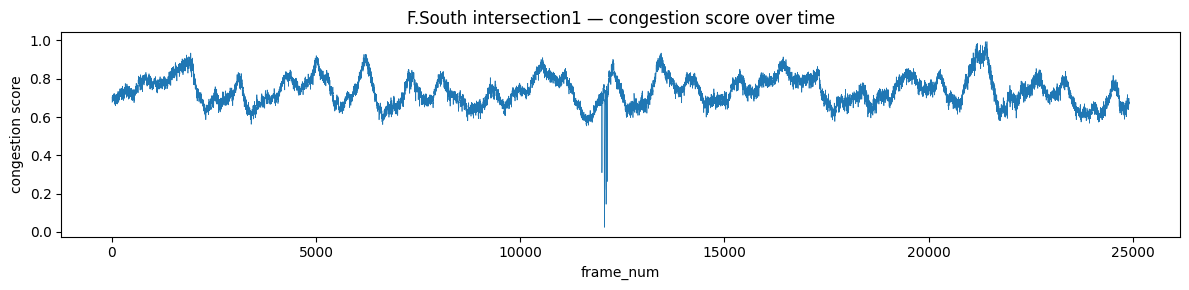

In [18]:
import matplotlib.pyplot as plt

source = "F.South intersection1"
subset = master[master['source'] == source].sort_values('frame_num')

plt.figure(figsize=(12, 3))
plt.plot(subset['frame_num'], subset['congestion_score'], linewidth=0.5)
plt.title(f"{source} — congestion score over time")
plt.xlabel('frame_num')
plt.ylabel('congestion score')
plt.tight_layout()
plt.savefig('fsouth_score.png', dpi=150)
plt.show()

In [19]:
subset = master[master['source'] == 'F.South intersection1'].sort_values('frame_num')
spike = subset[(subset['frame_num'] > 11800) & (subset['frame_num'] < 12200)]
print(spike[['frame_num', 'vehicle_count', 'avg_speed', 'pct_stopped', 'congestion_score']])  

        frame_num  vehicle_count  avg_speed  pct_stopped  congestion_score
154067      11801             79  13.316848     0.455696          0.647547
154068      11802             79  13.575367     0.443038          0.638481
154069      11803             78  13.536577     0.448718          0.641501
154070      11804             77  13.249727     0.454545          0.647952
154071      11805             77  13.181831     0.441558          0.643172
...           ...            ...        ...          ...               ...
154461      12195             58   7.408345     0.620690          0.800167
154462      12196             61   7.142393     0.639344          0.811966
154463      12197             60   6.790017     0.683333          0.836061
154464      12198             60   6.825217     0.666667          0.828266
154465      12199             61   6.865590     0.655738          0.822920

[399 rows x 5 columns]


In [21]:
# Save the scored master — this is your clean dataset going forward
master.to_csv("../data/master_congestion_scored.csv", index=False)
print(f"Saved: {master.shape}")
print(f"Columns: {list(master.columns)}")

Saved: (271245, 15)
Columns: ['frame_num', 'vehicle_count', 'avg_speed', 'std_speed', 'pct_stopped', 'median_speed', 'pct_turning', 'total_flow', 'up_flow', 'right_flow', 'down_flow', 'left_flow', 'flow_imbalance', 'source', 'congestion_score']


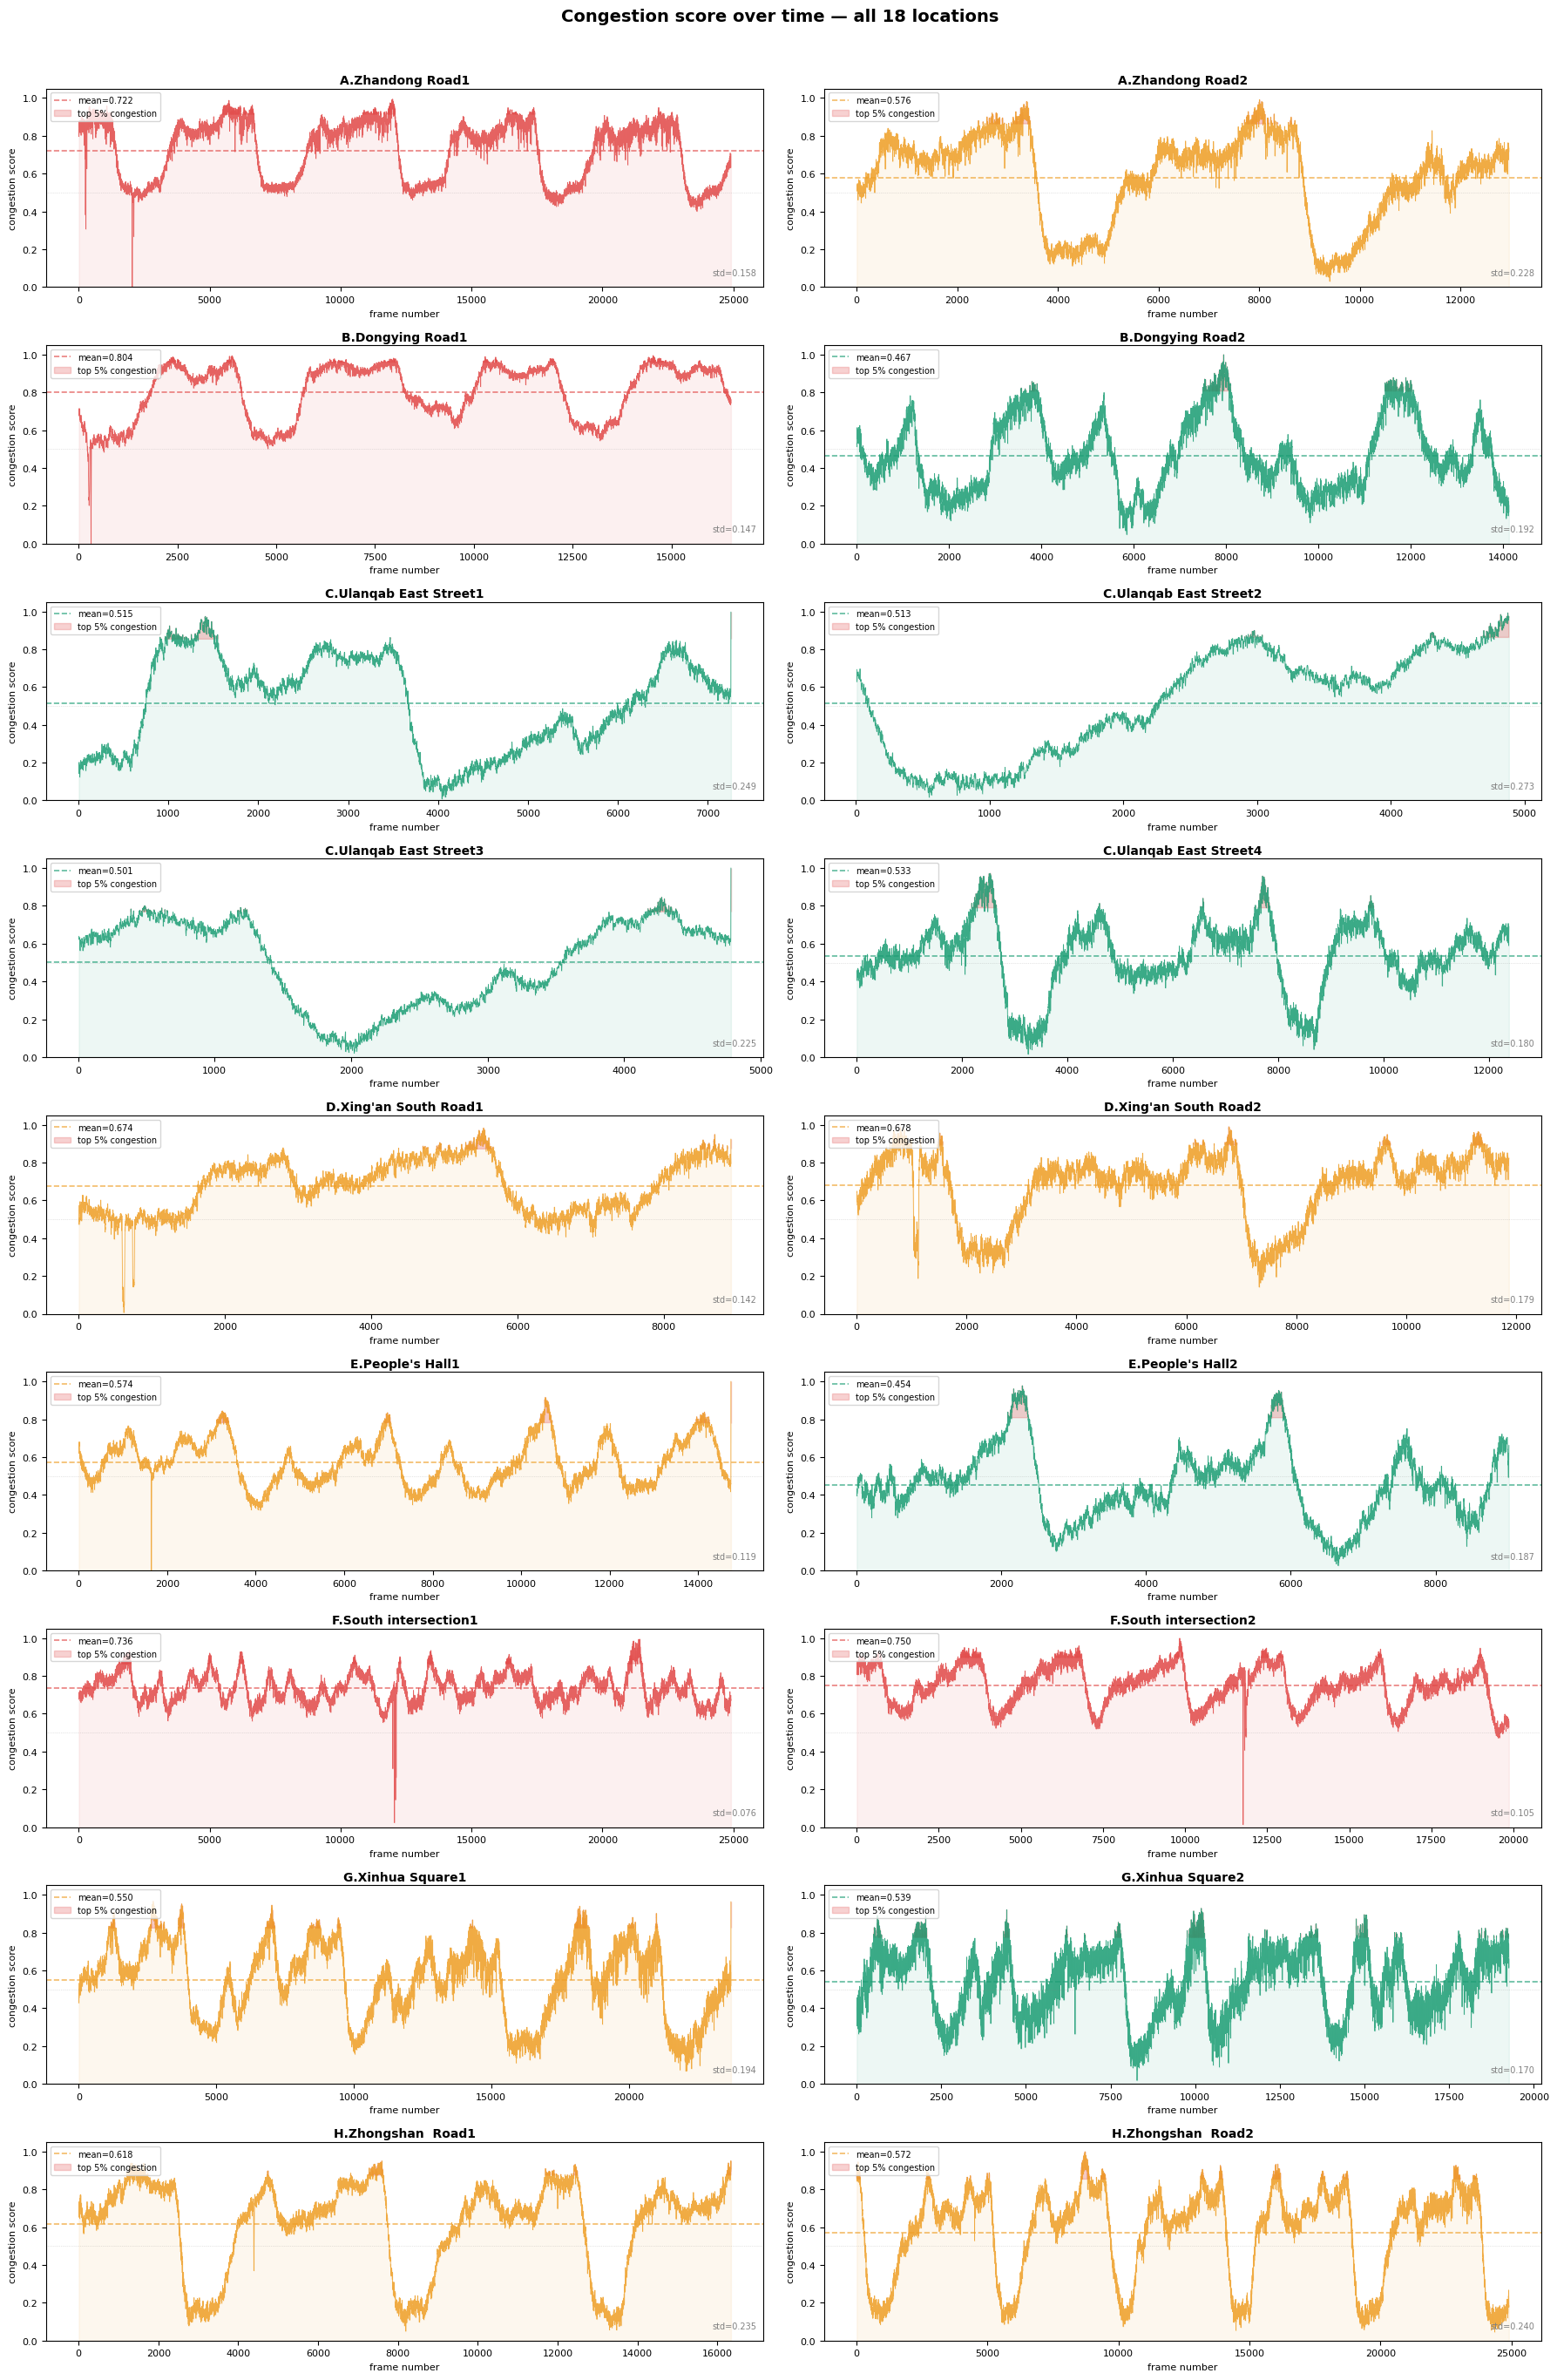

Saved to ../data/congestion_all_locations.png


In [22]:
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import numpy as np

# ── Load scored master ────────────────────────────────────
master = pd.read_csv("../data/master_congestion_scored.csv")
sources = sorted(master['source'].unique())

# ── Plot config ───────────────────────────────────────────
COLS = 2
ROWS = (len(sources) + 1) // COLS  # 9 rows for 18 locations

fig, axes = plt.subplots(ROWS, COLS, figsize=(18, ROWS * 3))
axes = axes.flatten()

for i, src in enumerate(sources):
    ax = axes[i]
    subset = master[master['source'] == src].sort_values('frame_num')

    score = subset['congestion_score'].values
    frames = subset['frame_num'].values
    mean_score = score.mean()

    # Color by severity
    if mean_score > 0.70:
        color = '#E24B4A'   # red — heavily congested
    elif mean_score > 0.55:
        color = '#EF9F27'   # amber — moderately congested
    else:
        color = '#1D9E75'   # green — relatively clear

    ax.plot(frames, score, linewidth=0.6, color=color, alpha=0.85)
    ax.fill_between(frames, score, alpha=0.08, color=color)

    # Reference lines
    ax.axhline(mean_score, color=color, linewidth=1.2,
               linestyle='--', alpha=0.7, label=f'mean={mean_score:.3f}')
    ax.axhline(0.5, color='gray', linewidth=0.5, linestyle=':', alpha=0.4)

    # Shade worst 5% of frames
    threshold = np.percentile(score, 95)
    ax.fill_between(frames, score, threshold,
                    where=(score >= threshold),
                    color='#E24B4A', alpha=0.25, label=f'top 5% congestion')

    ax.set_title(src, fontsize=10, fontweight='bold', pad=4)
    ax.set_ylim(0, 1.05)
    ax.set_xlabel('frame number', fontsize=8)
    ax.set_ylabel('congestion score', fontsize=8)
    ax.tick_params(labelsize=8)
    ax.legend(fontsize=7, loc='upper left')

    # Annotate std
    std_score = score.std()
    ax.text(0.99, 0.05, f'std={std_score:.3f}',
            transform=ax.transAxes, fontsize=7,
            ha='right', va='bottom', color='gray')

# Hide any unused axes
for j in range(len(sources), len(axes)):
    axes[j].set_visible(False)

fig.suptitle('Congestion score over time — all 18 locations',
             fontsize=14, fontweight='bold', y=1.01)
plt.tight_layout()
plt.savefig('../data/congestion_all_locations.png', dpi=150, bbox_inches='tight')
plt.show()
print("Saved to ../data/congestion_all_locations.png")

In [26]:
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
import numpy as np

def compute_congestion_score_pca(group):
    features = group[['avg_speed', 'pct_stopped']].copy()
    
    # Invert speed so both features point in same direction
    # (higher = more congested)
    features['avg_speed'] = -features['avg_speed']
    
    scaler = StandardScaler()
    scaled = scaler.fit_transform(features)
    
    pca = PCA(n_components=1)
    component = pca.fit_transform(scaled).flatten()
    
    # Normalize to 0-1
    group = group.copy()
    score = (component - component.min()) / (component.max() - component.min() + 1e-9)
    
    # PCA direction might be flipped — ensure high score = more congested
    if group.loc[group.index, 'pct_stopped'].corr(pd.Series(score, index=group.index)) < 0:
        score = 1 - score
        
    group['congestion_score_pca'] = score
    print(f"{group['source'].iloc[0]}: PCA weights → speed={pca.components_[0][0]:.3f}, stopped={pca.components_[0][1]:.3f}")
    return group

master = master.groupby('source', group_keys=False).apply(compute_congestion_score_pca)

A.Zhandong Road1: PCA weights → speed=0.707, stopped=0.707
A.Zhandong Road2: PCA weights → speed=0.707, stopped=0.707
B.Dongying Road1: PCA weights → speed=0.707, stopped=0.707
B.Dongying Road2: PCA weights → speed=0.707, stopped=0.707
C.Ulanqab East Street1: PCA weights → speed=0.707, stopped=0.707
C.Ulanqab East Street2: PCA weights → speed=0.707, stopped=0.707
C.Ulanqab East Street3: PCA weights → speed=0.707, stopped=0.707
C.Ulanqab East Street4: PCA weights → speed=0.707, stopped=0.707
D.Xing'an South Road1: PCA weights → speed=0.707, stopped=0.707
D.Xing'an South Road2: PCA weights → speed=0.707, stopped=0.707
E.People's Hall1: PCA weights → speed=0.707, stopped=0.707
E.People's Hall2: PCA weights → speed=0.707, stopped=0.707
F.South intersection1: PCA weights → speed=0.707, stopped=0.707
F.South intersection2: PCA weights → speed=0.707, stopped=0.707
G.Xinhua Square1: PCA weights → speed=0.707, stopped=0.707
G.Xinhua Square2: PCA weights → speed=0.707, stopped=0.707
H.Zhongshan 

In [27]:
print(master[['avg_speed','pct_stopped']].corr())
print()
print(master.groupby('source').apply(
    lambda g: g['avg_speed'].corr(g['pct_stopped'])
).round(3))

             avg_speed  pct_stopped
avg_speed     1.000000    -0.879801
pct_stopped  -0.879801     1.000000

source
A.Zhandong Road1         -0.955
A.Zhandong Road2         -0.921
B.Dongying Road1         -0.964
B.Dongying Road2         -0.869
C.Ulanqab East Street1   -0.953
C.Ulanqab East Street2   -0.965
C.Ulanqab East Street3   -0.972
C.Ulanqab East Street4   -0.909
D.Xing'an South Road1    -0.883
D.Xing'an South Road2    -0.835
E.People's Hall1         -0.836
E.People's Hall2         -0.854
F.South intersection1    -0.716
F.South intersection2    -0.896
G.Xinhua Square1         -0.853
G.Xinhua Square2         -0.799
H.Zhongshan  Road1       -0.920
H.Zhongshan  Road2       -0.920
dtype: float64


In [28]:
def compute_congestion_score_final(group):
    spd = group['avg_speed']
    # Invert and normalize: slow = high score
    score = 1 - (spd - spd.min()) / (spd.max() - spd.min() + 1e-9)
    group = group.copy()
    group['congestion_score'] = score
    return group

master = master.groupby('source', group_keys=False).apply(compute_congestion_score_final)

# Quick sanity check
print(master.groupby('source')['congestion_score'].describe().round(3))

                          count   mean    std  min    25%    50%    75%  max
source                                                                      
A.Zhandong Road1        24903.0  0.826  0.124  0.0  0.685  0.891  0.928  1.0
A.Zhandong Road2        12955.0  0.631  0.241  0.0  0.521  0.716  0.807  1.0
B.Dongying Road1        16499.0  0.830  0.146  0.0  0.711  0.906  0.952  1.0
B.Dongying Road2        14120.0  0.494  0.207  0.0  0.349  0.463  0.675  1.0
C.Ulanqab East Street1   7251.0  0.523  0.268  0.0  0.266  0.591  0.757  1.0
C.Ulanqab East Street2   4879.0  0.538  0.296  0.0  0.217  0.640  0.815  1.0
C.Ulanqab East Street3   4776.0  0.523  0.245  0.0  0.299  0.627  0.737  1.0
C.Ulanqab East Street4  12374.0  0.544  0.193  0.0  0.461  0.558  0.673  1.0
D.Xing'an South Road1    8914.0  0.711  0.152  0.0  0.559  0.747  0.844  1.0
D.Xing'an South Road2   11858.0  0.668  0.212  0.0  0.626  0.735  0.801  1.0
E.People's Hall1        14734.0  0.604  0.134  0.0  0.490  0.600  0.715  1.0

In [29]:
import numpy as np

def fix_anomalies(group):
    score = group['congestion_score'].copy()
    mean  = score.mean()
    std   = score.std()
    
    # Flag frames more than 3 std below mean as anomalies
    anomaly_mask = score < (mean - 3 * std)
    n_anomalies  = anomaly_mask.sum()
    
    if n_anomalies > 0:
        print(f"{group['source'].iloc[0]}: fixed {n_anomalies} anomalous frames")
        score[anomaly_mask] = np.nan
        score = score.interpolate(method='linear')
    
    group = group.copy()
    group['congestion_score'] = score
    return group

master = master.groupby('source', group_keys=False).apply(fix_anomalies)

# Re-normalize after fixing — anomaly skewed the min
def renormalize(group):
    spd = group['avg_speed']
    score = 1 - (spd - spd.min()) / (spd.max() - spd.min() + 1e-9)
    group = group.copy()
    group['congestion_score'] = score
    return group

master = master.groupby('source', group_keys=False).apply(renormalize)

# Save final clean version
master.to_csv("../data/master_congestion_final.csv", index=False)
print(f"\nFinal dataset saved: {master.shape}")
print(f"Columns: {list(master.columns)}")

A.Zhandong Road1: fixed 8 anomalous frames
B.Dongying Road1: fixed 28 anomalous frames
D.Xing'an South Road1: fixed 36 anomalous frames
D.Xing'an South Road2: fixed 2 anomalous frames
E.People's Hall1: fixed 4 anomalous frames
F.South intersection1: fixed 35 anomalous frames
F.South intersection2: fixed 7 anomalous frames

Final dataset saved: (271245, 16)
Columns: ['frame_num', 'vehicle_count', 'avg_speed', 'std_speed', 'pct_stopped', 'median_speed', 'pct_turning', 'total_flow', 'up_flow', 'right_flow', 'down_flow', 'left_flow', 'flow_imbalance', 'source', 'congestion_score', 'congestion_score_pca']


In [33]:
master.to_csv("../data/master_congestion_final.csv", index=False)
print(f"Saved: {master.shape}")
print(f"Columns: {list(master.columns)}")

Saved: (271245, 17)
Columns: ['frame_num', 'vehicle_count', 'avg_speed', 'std_speed', 'pct_stopped', 'median_speed', 'pct_turning', 'total_flow', 'up_flow', 'right_flow', 'down_flow', 'left_flow', 'flow_imbalance', 'source', 'congestion_score', 'congestion_score_pca', 'avg_speed_clean']
